In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline 

import sys
sys.path.insert(0, "py_src")
sys.path.insert(0, "../py_src")
sys.path.insert(0, "../../py_src")

from pathlib import Path
import base64
import json
import voxeloo
from dataclasses import dataclass
from typing import Tuple
from tqdm.auto import tqdm
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d
import skimage

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
terrain_names = json.load(open("../../src/shared/asset_defs/gen/terrain.json"))

In [3]:
@dataclass
class TerrainVoxel:
    name: str
    color: int
    
    @property
    def idx(self):
        return terrain_names[self.name]

terrain_voxels = [
  TerrainVoxel("none", 0x00000000),
  TerrainVoxel("basalt", 0x323143ff),
  TerrainVoxel("bedrock", 0x4d3f53ff),
  TerrainVoxel("birch_log", 0xb9c8d2ff),
  TerrainVoxel("clay", 0x755a56ff),
  TerrainVoxel("coal_ore", 0x2f2d34ff),
  TerrainVoxel("cobblestone", 0x706e76ff),
  TerrainVoxel("diamond_ore", 0x36d9f1ff),
  TerrainVoxel("dirt", 0x9b633cff),
  TerrainVoxel("gold_ore", 0xded02cff),
  TerrainVoxel("granite", 0xb2bcc7ff),
  TerrainVoxel("grass", 0x30a144ff),
  TerrainVoxel("gravel", 0xad8c64ff),
  TerrainVoxel("hay", 0xcdb158ff),
  TerrainVoxel("limestone", 0x8b7b70ff),
  TerrainVoxel("moss", 0x247447ff),
  TerrainVoxel("neptunium_ore", 0x394f57ff),
  TerrainVoxel("oak_log", 0x774530ff),
  TerrainVoxel("pumpkin", 0xc67a2bff),
  TerrainVoxel("quartzite", 0x527d79ff),
  TerrainVoxel("rubber_log", 0x603526ff),
  TerrainVoxel("silver_ore", 0x7f9cbaff),
  TerrainVoxel("stone", 0x828690ff),
  TerrainVoxel("snow", 0xe5f6faff),

  TerrainVoxel("basalt_brick", 0x323143ff),
  TerrainVoxel("basalt_carved", 0x323143ff),
  TerrainVoxel("basalt_polished", 0x323143ff),
  TerrainVoxel("basalt_shingles", 0x323143ff),
  TerrainVoxel("birch_lumber", 0xc29b44ff),
  TerrainVoxel("clay_brick", 0x883b49ff),
  TerrainVoxel("clay_carved", 0x883b49ff),
  TerrainVoxel("clay_polished", 0x883b49ff),
  TerrainVoxel("clay_shingles", 0x883b49ff),
  TerrainVoxel("cobblestone_brick", 0x706e76ff),
  TerrainVoxel("cobblestone_carved", 0x706e76ff),
  TerrainVoxel("cobblestone_polished", 0x706e76ff),
  TerrainVoxel("cobblestone_shingles", 0x706e76ff),
  TerrainVoxel("cotton_fabric", 0xe9e8e9ff),
  TerrainVoxel("diamond", 0xa6f6ffff),
  TerrainVoxel("gold", 0xf7ca00ff),
  TerrainVoxel("granite_brick", 0xb2bcc7ff),
  TerrainVoxel("granite_carved", 0xb2bcc7ff),
  TerrainVoxel("granite_polished", 0xb2bcc7ff),
  TerrainVoxel("granite_shingles", 0xb2bcc7ff),
  TerrainVoxel("limestone_brick", 0x8b7b70ff),
  TerrainVoxel("limestone_carved", 0x8b7b70ff),
  TerrainVoxel("limestone_polished", 0x8b7b70ff),
  TerrainVoxel("limestone_shingles", 0x8b7b70ff),
  TerrainVoxel("mushroom_leather", 0x7c5a45ff),
  TerrainVoxel("neptunium", 0x224a3eff),
  TerrainVoxel("oak_lumber", 0x8b572aff),
  TerrainVoxel("quartzite_brick", 0x527d79ff),
  TerrainVoxel("quartzite_carved", 0x527d79ff),
  TerrainVoxel("quartzite_polished", 0x527d79ff),
  TerrainVoxel("quartzite_shingles", 0x527d79ff),
  TerrainVoxel("rubber_lumber", 0x764330ff),
  TerrainVoxel("silver", 0xccd6dbff),
  TerrainVoxel("stone_brick", 0x828690ff),
  TerrainVoxel("stone_carved", 0x828690ff),
  TerrainVoxel("stone_polished", 0x828690ff),
  TerrainVoxel("stone_shingles", 0x828690ff),
  TerrainVoxel("wood_crate", 0x8b572aff),

  TerrainVoxel("oak_leaf", 0x125d37ff),
  TerrainVoxel("birch_leaf", 0x4e6a1dff),
  TerrainVoxel("rubber_leaf", 0x20575aff),
  TerrainVoxel("switch_grass", 0x4bbb47ff),
  TerrainVoxel("azalea_flower", 0xc86c8dff),
  TerrainVoxel("bell_flower", 0x59a5d5ff),
  TerrainVoxel("dandelion_flower", 0xd0c227ff),
  TerrainVoxel("daylily_flower", 0xcd8216ff),
  TerrainVoxel("lilac_flower", 0xa767f2ff),
  TerrainVoxel("rose_flower", 0xcc374cff),
  TerrainVoxel("cotton_bush", 0xe9e8e9ff),
  TerrainVoxel("hemp_bush", 0x2b6230ff),
  TerrainVoxel("red_mushroom", 0xb02f3aff),
]

omitted_names = set([
  "switch_grass",
  "azalea_flower",
  "bell_flower",
  "dandelion_flower",
  "daylily_flower",
  "lilac_flower",
  "rose_flower",
  "cotton_bush",
  "hemp_bush",
  "red_mushroom",
  "birch_leaf",
  "oak_leaf",
  "rubber_leaf",
  "birch_log",
  "oak_log",
  "rubber_log"
])

terrain_by_index = {e.idx: e for e in terrain_voxels if e.name != "none" and e.name not in omitted_names}
valid_indexes = np.array(list(terrain_by_index.keys()))

In [4]:
@dataclass
class Block:
    array: voxeloo.biomes.VolumeBlock_U32
    box: Tuple[Tuple[int, int, int], Tuple[int, int, int]]
        
@dataclass
class HeightMaterialBlock:
    height_material: np.ndarray
    box: Tuple[Tuple[int, int, int], Tuple[int, int, int]]

In [5]:
def last_nonzero(a):
    return a.shape[1] - (a!=0)[:,::-1].argmax(1) - 1

def read_as_dense(path):
    with open(path) as f:
        j = json.load(f)
    
    v = voxeloo.biomes.VolumeBlock_U32()
    v.loads(j["block"])
    
    return Block(array=v.array(), box=j["box"])

def make_depth_material(block):
    d = block.array.copy()
    d[~np.isin(d, valid_indexes)] = 0
    depth = last_nonzero(d)
    material = np.take_along_axis(d, depth.reshape(32, 1, 32), axis=1).reshape(32, 32)
    dm = np.zeros((2, 32, 32))
    dm[0, :, :] = block.box[0][1] + depth 
    dm[1, :, :] = material
    
    return HeightMaterialBlock(
        height_material=dm,
        box=block.box
    )

In [6]:
all_blocks = list(tqdm(make_depth_material(read_as_dense(e)) for e in Path("/home/tdimson/projects/zones/data").glob("*.dat")))
min_boundary = np.array(min(e.box[0] for e in all_blocks))
max_boundary = np.array(max(e.box[1] for e in all_blocks))
size = max_boundary - min_boundary

0it [00:00, ?it/s]

In [7]:
mega_dm = np.zeros((2, size[2], size[0]))
mega_dm[0, :, :] = -10000

for i, b in enumerate(reversed(all_blocks)):
    pos = np.array(b.box[0]) - min_boundary
    dm_s = mega_dm[:, pos[2]:(pos[2] + 32), pos[0]:(pos[0] + 32)]
    block_dm = b.height_material
    losses = (dm_s[0, :, :] < block_dm[0, :, :]) & (block_dm[1, :, :] != 0)
    
    dm_s[0, losses] = block_dm[0, losses]
    dm_s[1, losses] = block_dm[1, losses]

In [103]:
height_map = mega_dm[0, :, :]
edgeXF = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1],
])
edgeYF = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

edgeX = convolve2d(height_map, edgeXF, mode='same')
edgeY = convolve2d(height_map, edgeYF, mode='same')
grad = np.sqrt(edgeX ** 2 + edgeY ** 2)
dim = 1.0 - np.minimum(grad * 0.02, 0.5)

In [93]:
tester = skimage.filters.prewitt(height_map)
tester = np.clip( (1 - tester * 0.1), 0, 1)

In [94]:
image = np.zeros((mega_dm.shape[2], mega_dm.shape[1], 3), dtype='uint8')
for z in range(mega_dm.shape[1]):
    for x in range(mega_dm.shape[2]):
        m = mega_dm[1, z, x]
        if m in terrain_by_index:
            image[z, x, 0] = (terrain_by_index[m].color >> 24) & 0xFF
            image[z, x, 1] = (terrain_by_index[m].color >> 16) & 0xFF
            image[z, x, 2] = (terrain_by_index[m].color >> 8) & 0xFF

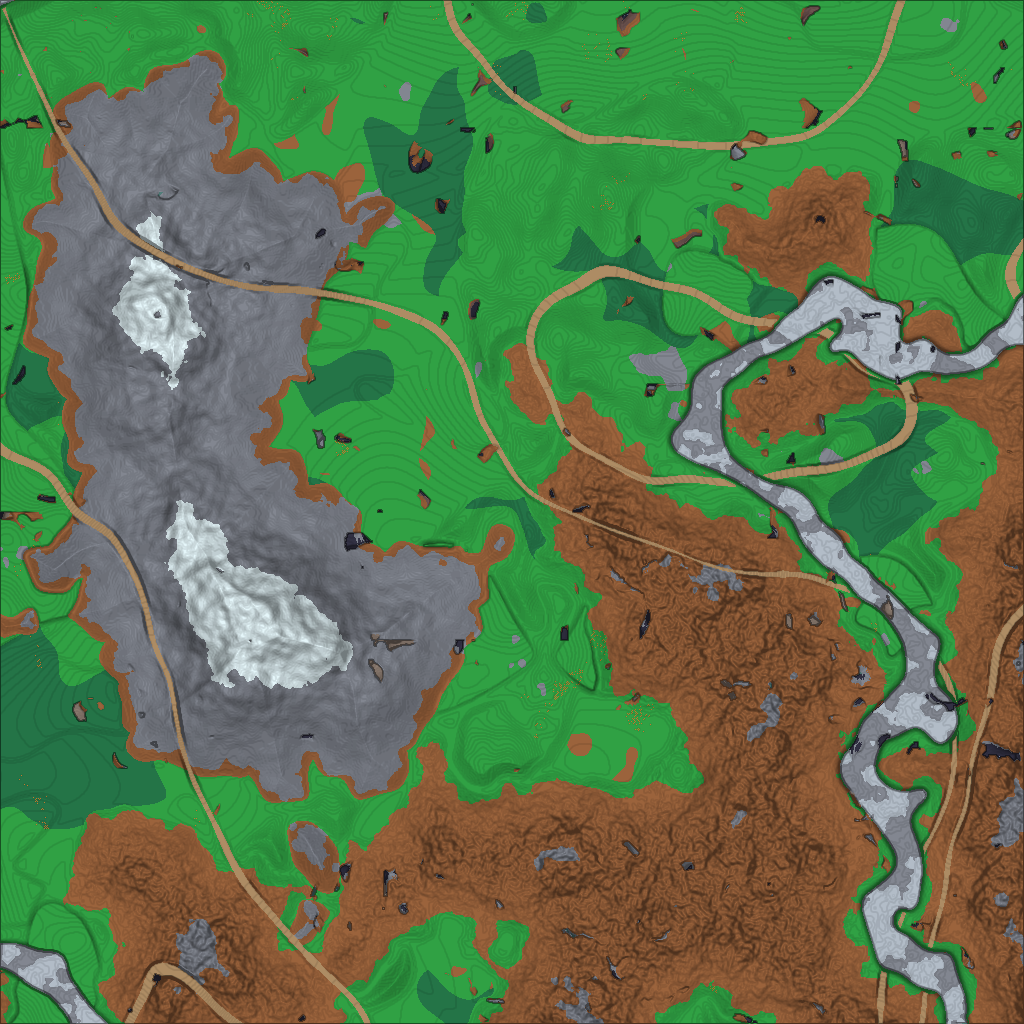

In [104]:
Image.fromarray(np.uint8(image * dim.reshape((1024, 1024, 1)))).convert('RGB')